In [1]:
# Importing the necessary libraries for data manipulation and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# CFPB Dataset Loading, Preprocessing, and Feature Engineering

Objective: prepare a clean, analysis-ready CFPB complaints dataset and generate monthly aggregated time-series tables for downstream modeling notebooks.

This notebook covers:
- full-dataset diagnostics (size, coverage, missingness, product mix)
- feature engineering for time and geography (`year_quarter`, `region`)
- product label normalization for stable trend analysis
- monthly aggregation and export for credit reporting forecasting tracks

Primary outputs generated in this notebook:
- cleaned complaints parquet for downstream EDA
- monthly credit reporting tables for all regions, South, and non-South
- binary-feature aggregates useful as exogenous regressors in time-series modeling

# 1. Project Context

## 1.1 Background

CFPB complaint records provide longitudinal signals about consumer pain points across products, institutions, and geographies. This notebook builds the shared preparation layer used by later EDA and forecasting notebooks.

## 1.2 Research Questions

- RQ1: Do Southern-region complaint trajectories differ from non-Southern trajectories in trend and variability?
- RQ2: Which model families are most reliable for forecasting credit reporting complaint dynamics?
- RQ3: How does the share of credit reporting complaints evolve through the study period?

## 1.3 Practical Relevance

- CFPB operations: planning investigations, staffing, and regional oversight.
- Financial institutions: proactive service/compliance capacity planning.
- Consumers/advocates: clearer transparency on complaint pressure over time.

## 1.4 Scope Notes and Limitations

- Forecasts are descriptive/predictive, not causal.
- External shocks can break historical patterns.
- Product-level grouping reduces sparsity but can mask sub-issue heterogeneity.
- Geography is analyzed primarily as South vs non-South for comparability in downstream models.

# 2. Data Description

## 2.1 Source and Coverage

The source is the CFPB Consumer Complaint Database (public). This notebook uses the project snapshot and then constrains the analysis window to complete months to support stable monthly/quarterly comparisons.

## 2.2 Core Field Definitions

- `Date received`: complaint intake date used for temporal aggregation.
- `Product`: top-level complaint category.
- `State`: U.S. state/territory code used for region mapping.
- `Submitted via`: submission channel (web, phone, etc.).
- `Consumer consent provided?`, `Timely response?`, `Consumer disputed?`: response-process fields later transformed into binary indicators.

# 3. Exploratory Data Analysis (EDA) #1 - Full Dataset EDA

This section establishes baseline context before modeling-specific filtering:
- dataset size and date span
- field-level missingness
- dominant products and channels
- high-level volume trends over time

In [2]:
# Loading the full dataset
df = pd.read_csv(r"..\data\complaints.csv")

In [3]:
# Display the shape and column names of the loaded dataset
print(f"The loaded dataset has {df.shape[0]:,} rows, and {df.shape[1]:,} columns as follows:\n{df.columns.tolist()}")

The loaded dataset has 13,843,560 rows, and 18 columns as follows:
['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']


In [4]:
# Preview core fields from the full dataset
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2020-07-13,Mortgage,FHA mortgage,Trouble during payment process,NaN,"I currently have my mortgage with GMFS, servic...",NaN,"SAMC Honebee TRS, LLC",AL,36695,NaN,Consent provided,Web,2020-07-13,Closed with explanation,Yes,NaN,3743391
1,2023-12-16,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,"FactorTrust, Inc.",NY,13224,NaN,Consent not provided,Web,2023-12-16,Closed with explanation,Yes,NaN,8011171
2,2024-01-27,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,NaN,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",NY,11714,NaN,Consent not provided,Web,2024-01-27,Closed with non-monetary relief,Yes,NaN,8236394
3,2019-05-22,"Credit reporting, credit repair services, or o...",Credit reporting,Problem with fraud alerts or security freezes,NaN,Have had a couple years of problems getting an...,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,CA,95628,Older American,Consent provided,Web,2019-05-22,Closed with explanation,Yes,NaN,3251015
4,2023-12-21,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Personal information incorrect,NaN,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,FL,32703,NaN,Consent not provided,Web,2023-12-21,Closed with explanation,Yes,NaN,8032795


In [5]:
# Ensure Date received is datetime for time-based summaries/plots
if not pd.api.types.is_datetime64_any_dtype(df["Date received"]):
    df["Date received"] = pd.to_datetime(df["Date received"], errors="coerce")

In [6]:
# Summarize the size, coverage, and cardinality of the raw dataset
dataset_overview = pd.DataFrame(
    {
        "metric": [
            "Rows",
            "Columns",
            "Date coverage start",
            "Date coverage end",
            "Unique products",
            "Unique sub-products",
            "Unique companies",
            "Unique states",
            "In-memory size (GB)",
        ],
        "value": [
            f"{len(df):,}",
            df.shape[1],
            df["Date received"].min().date(),
            df["Date received"].max().date(),
            df["Product"].nunique(dropna=True),
            df["Sub-product"].nunique(dropna=True),
            df["Company"].nunique(dropna=True),
            df["State"].nunique(dropna=True),
            round(df.memory_usage(deep=True).sum() / 1024**3, 2),
        ],
    }
)

print("Key characteristics of the dataset:")
dataset_overview

Key characteristics of the dataset:


,metric,value
0,Rows,"13,843,560"
1,Columns,18
2,Date coverage start,2011-12-01
3,Date coverage end,2026-02-24
4,Unique products,21
5,Unique sub-products,86
6,Unique companies,7833
7,Unique states,63
8,In-memory size (GB),16.73


In [7]:
# Cut off date coverage end to the last full-month data (i.e., month ending 31 January 2026)
cutoff_date_start = pd.to_datetime("2012-01-01")
cutoff_date_end = pd.to_datetime("2025-12-31")
df = df[(df["Date received"] >= cutoff_date_start) & (df["Date received"] <= cutoff_date_end)]

print(f"The dataset's coverage end date is now bounded within {cutoff_date_start.date()} and {cutoff_date_end.date()} to ensure we only analyze complete quarters of data.")

The dataset's coverage end date is now bounded within 2012-01-01 and 2025-12-31 to ensure we only analyze complete quarters of data.


In [8]:
# Inspect missingness across the full-dataset fields used in this notebook
missingness_summary = (
    df.isna()
      .mean()
      .mul(100)
      .round(2)
      .rename_axis("column")
      .reset_index(name="missing_pct")
      .sort_values(["missing_pct", "column"], ascending=[False, True])
      .reset_index(drop=True)
)

print("Missingness summary for key fields:")
missingness_summary

Missingness summary for key fields:


,column,missing_pct
0,Tags,94.55
1,Consumer disputed?,94.03
2,Consumer complaint narrative,70.98
3,Company public response,44.91
4,Consumer consent provided?,10.81
5,Sub-issue,6.83
6,Sub-product,1.82
7,State,0.46
8,ZIP code,0.24
9,Company,0.00


,product,complaint_count
11,Credit reporting or other personal consumer re...,7729028
10,"Credit reporting, credit repair services, or o...",2163844
9,Debt collection,969211
8,Mortgage,435553
7,Checking or savings account,334214
6,Credit card,276431
5,Credit card or prepaid card,206368
4,"Money transfer, virtual currency, or money ser...",164849
3,Credit reporting,140429
2,Student loan,119047


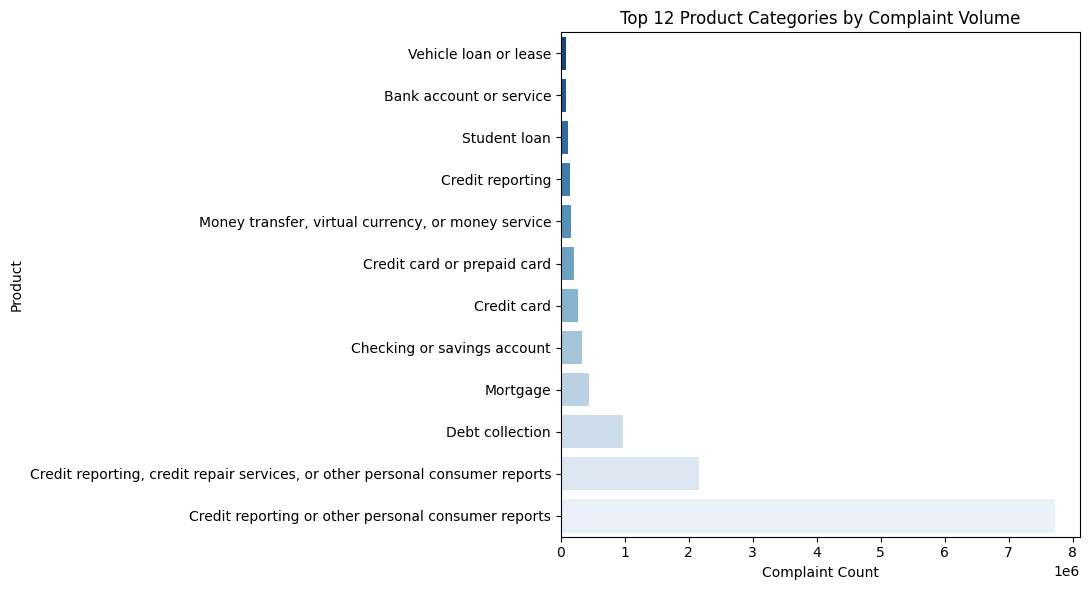

In [9]:
# Visualize the dominant complaint products in the full dataset
product_counts = (
    df["Product"]
      .fillna("Missing")
      .value_counts()
      .head(12)
      .sort_values()
      .rename_axis("product")
      .reset_index(name="complaint_count")
)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(
    data=product_counts,
    x="complaint_count",
    y="product",
    palette="Blues_r",
    ax=ax,
    hue="product",
    legend=False,
 )
ax.set_title("Top 12 Product Categories by Complaint Volume")
ax.set_xlabel("Complaint Count")
ax.set_ylabel("Product")
plt.tight_layout()

product_counts.sort_values("complaint_count", ascending=False)

,submitted_via,complaint_count
6,Web,12224714
5,Referral,267517
4,Phone,209507
3,Postal mail,106634
2,Fax,25647
1,Web Referral,1240
0,Email,414


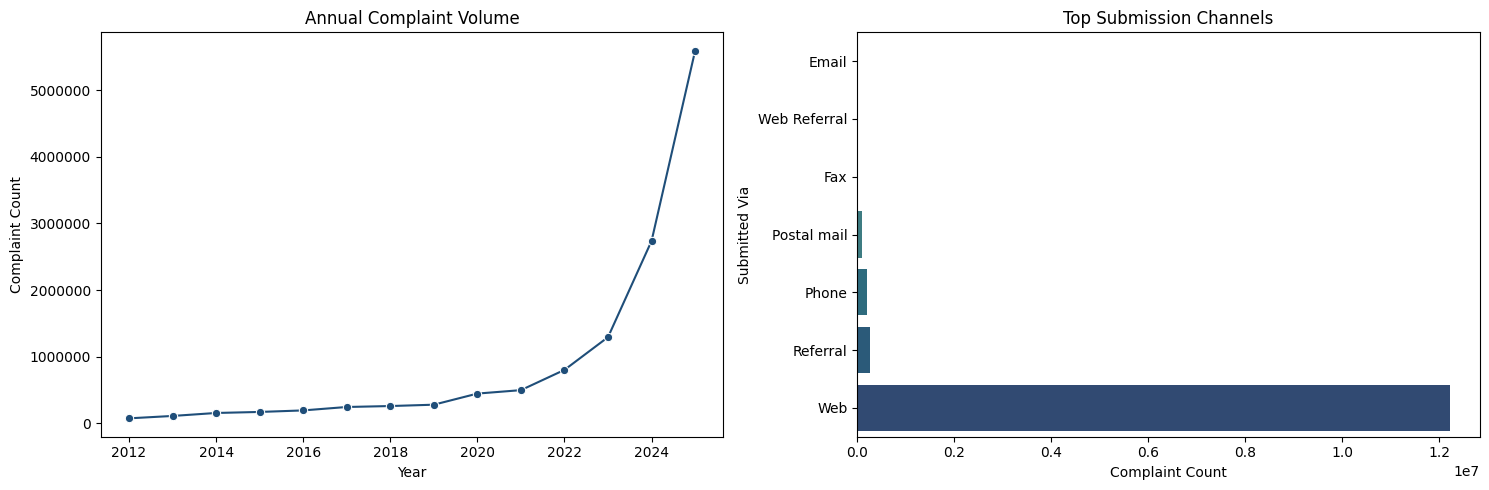

In [10]:
# Plot overall complaint volume through time and summarize submission channels
yearly_counts = (
    df.assign(year=df["Date received"].dt.year)
      .groupby("year")
      .size()
      .reset_index(name="complaint_count")
)

submission_counts = (
    df["Submitted via"]
      .fillna("Missing")
      .value_counts()
      .head(8)
      .sort_values()
      .rename_axis("submitted_via")
      .reset_index(name="complaint_count")
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.lineplot(
    data=yearly_counts,
    x="year",
    y="complaint_count",
    marker="o",
    color="#1f4e79",
    ax=axes[0],
)
axes[0].set_title("Annual Complaint Volume")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Complaint Count")
axes[0].ticklabel_format(style="plain", axis="y")

sns.barplot(
    data=submission_counts,
    x="complaint_count",
    y="submitted_via",
    palette="crest",
    ax=axes[1],
    hue="submitted_via",
    legend=False,
 )
axes[1].set_title("Top Submission Channels")
axes[1].set_xlabel("Complaint Count")
axes[1].set_ylabel("Submitted Via")

plt.tight_layout()

submission_counts.sort_values("complaint_count", ascending=False)

# 4. Feature Engineering (#1) for Stratified and Time-Based Analysis

This section creates reusable temporal and geographic features used by downstream notebooks.

## 4.1 Create `year_quarter`

`year_quarter` converts each complaint date into a quarter label (for example `2021Q3`), enabling quarter-level trend comparisons and product-level pivoting.

In [11]:
# Create a year-quarter feature for time-based analyses
df['year_quarter'] = (
    df['Date received']
      .dt.to_period('Q')
      .astype(str)
)

Definition: `year_quarter` is a period key derived from `Date received` and formatted as `YYYYQ#` for consistent quarter-based grouping.

## 4.2 Map `State` to `region`

State codes are grouped into U.S. Census-style regions to reduce sparsity and improve interpretability.

Region definitions:
- Northeast: CT, ME, MA, NH, RI, VT, NJ, NY, PA
- Midwest: IL, IN, MI, OH, WI, IA, KS, MN, MO, NE, ND, SD
- South: DE, FL, GA, MD, NC, SC, VA, DC, WV, AL, KY, MS, TN, AR, LA, OK, TX
- West: AZ, CO, ID, MT, NV, NM, UT, WY, AK, CA, HI, OR, WA
- Other: remaining values (for example territories or non-state codes)

Definition: `region` is the aggregated geography field used for South vs non-South comparative tracks.

In [12]:
# Map states to US regions for geographic analyses
northeast = ['CT','ME','MA','NH','RI','VT','NJ','NY','PA']
midwest   = ['IL','IN','MI','OH','WI','IA','KS','MN','MO','NE','ND','SD']
south     = ['DE','FL','GA','MD','NC','SC','VA','DC','WV',
             'AL','KY','MS','TN','AR','LA','OK','TX']
west      = ['AZ','CO','ID','MT','NV','NM','UT','WY','AK','CA','HI','OR','WA']

def map_region(state):
    if state in northeast:
        return 'Northeast'
    elif state in midwest:
        return 'Midwest'
    elif state in south:
        return 'South'
    elif state in west:
        return 'West'
    else:
        return 'Other'

df['region'] = df['State'].apply(map_region)

This check validates that the `region` mapping behaves as expected and confirms the South/non-South segmentation is usable for comparative monthly modeling.

In [13]:
# Display the distribution of complaints across regions to check for any anomalies or dominant regions
print(f"Proportion of complaints by region:\n{df['region'].value_counts(normalize=True).apply(lambda x: f'{x:.2%}')}")

Proportion of complaints by region:
region
South        53.64%
West         16.26%
Northeast    16.04%
Midwest      13.17%
Other         0.89%
Name: proportion, dtype: object


# 5. EDA #2 - Product-Level EDA

## 5.1 EDA of All Products

This section visualizes complaint dynamics by product after temporal/geographic feature creation.

Interpretation notes:
- linear-scale charts highlight dominant products
- log-scale charts reveal movement in lower-volume categories
- pivot tables support side-by-side product-quarter comparisons used in downstream checks

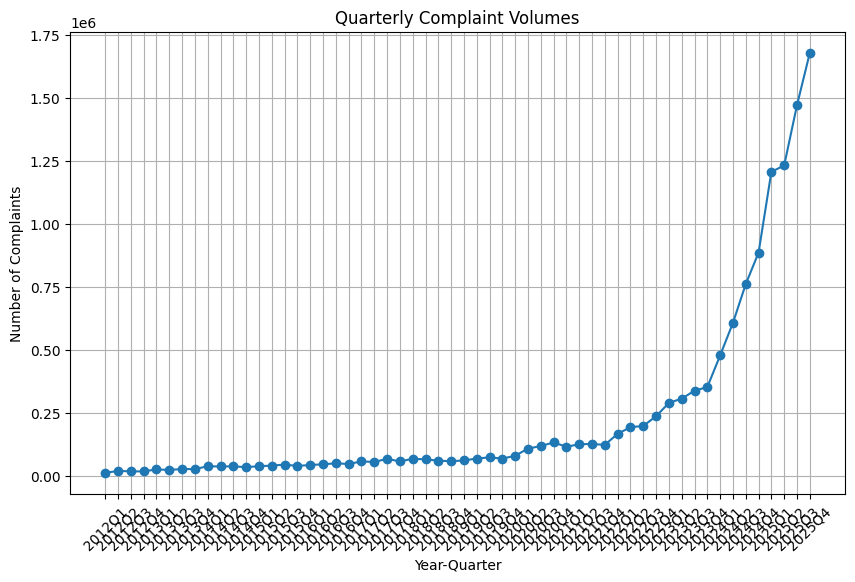

In [14]:
# Generate total number of complaints for each quarter
quarterly_complaints = df.groupby('year_quarter').size().reset_index(name='num_complaints')

# Plot the quarterly complaint volumes
plt.figure(figsize=(10, 6))
plt.plot(quarterly_complaints['year_quarter'], quarterly_complaints['num_complaints'], marker='o')
plt.title('Quarterly Complaint Volumes')
plt.xlabel('Year-Quarter')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

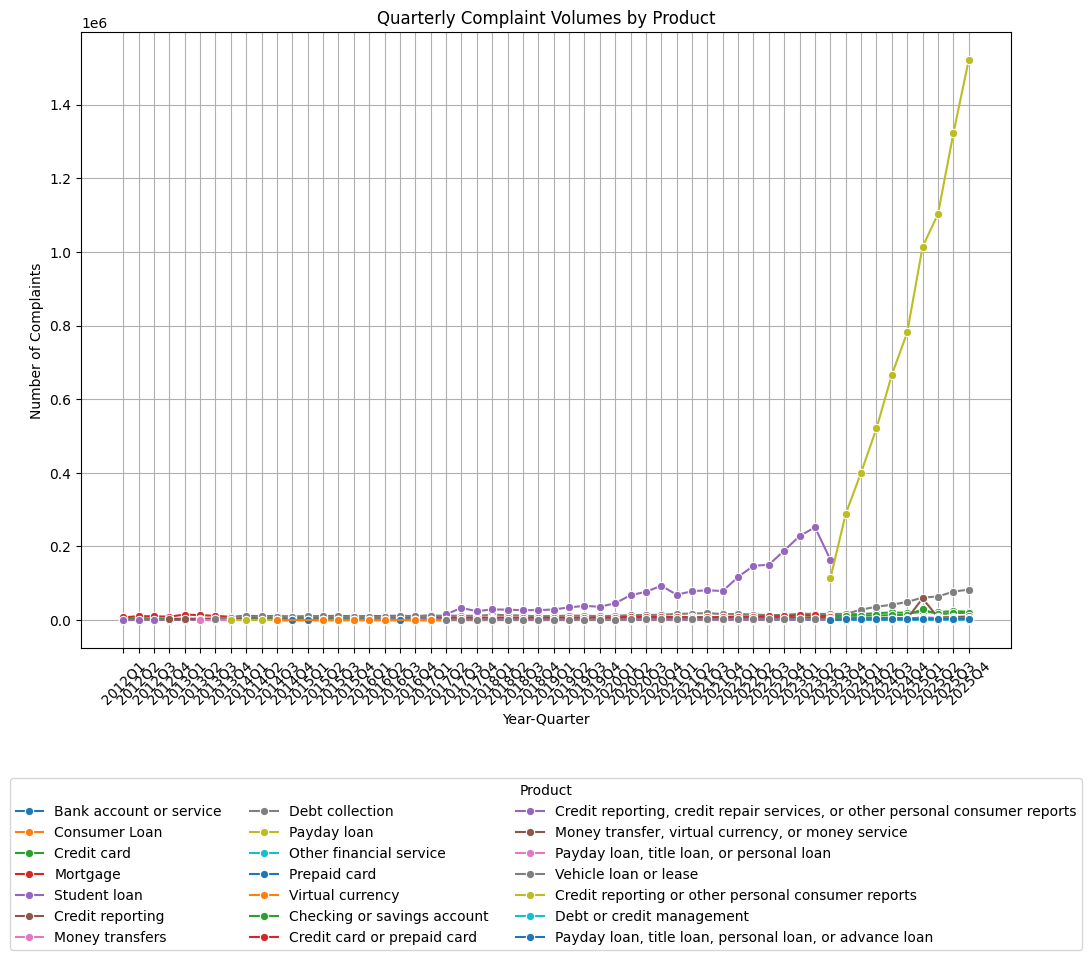

In [15]:
# Create the distribution of complaints by product per quarter
product_counts_qtr = df.groupby(['year_quarter', 'Product']).size().reset_index(name='num_complaints')

# Plot the distribution of complaints by product per quarter
plt.figure(figsize=(12, 8))
sns.lineplot(
    data=product_counts_qtr,
    x='year_quarter',
    y='num_complaints',
    hue='Product',
    marker='o',
    palette='tab10'
)
plt.title('Quarterly Complaint Volumes by Product')
plt.xlabel('Year-Quarter')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45)
plt.legend(title='Product', loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=True)
plt.grid(True)
#plt.tight_layout()
plt.show()

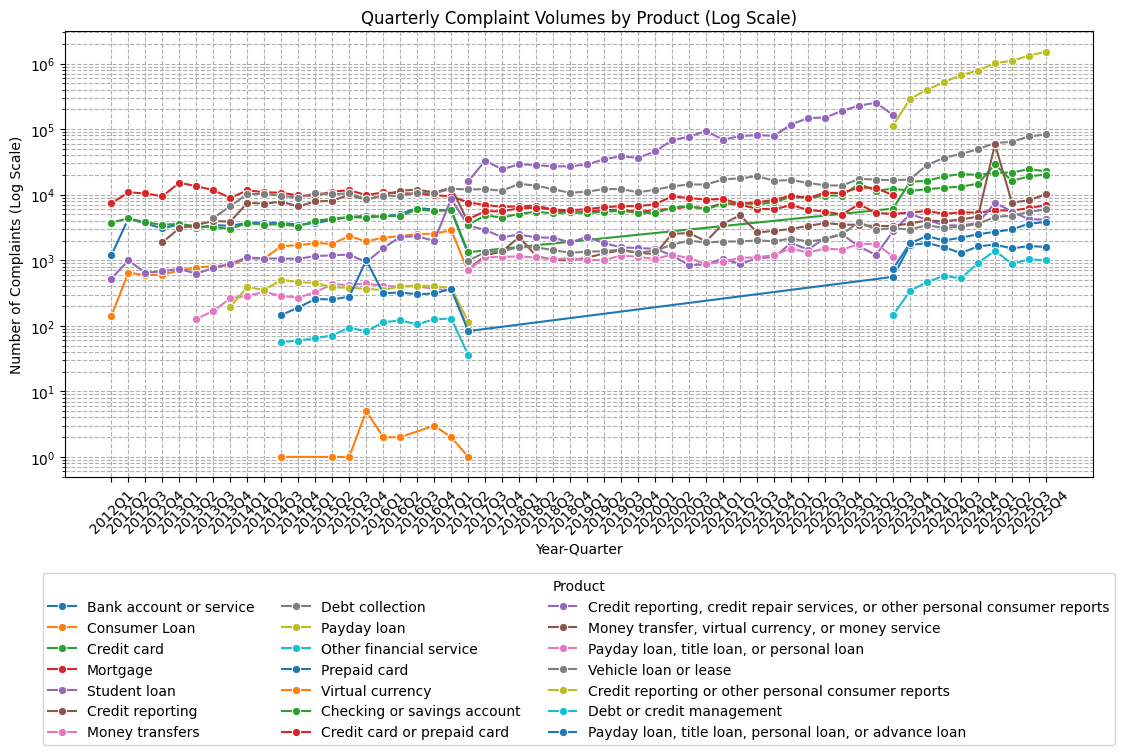

In [16]:
# Plotting a log-transformed product_counts_qtr to better visualize trends for less common products
plt.figure(figsize=(12, 8))
sns.lineplot(
    data=product_counts_qtr,
    x='year_quarter',
    y='num_complaints',
    hue='Product',
    marker='o',
    palette='tab10'
)
plt.title('Quarterly Complaint Volumes by Product (Log Scale)')
plt.xlabel('Year-Quarter')
plt.ylabel('Number of Complaints (Log Scale)')
plt.yscale('log')
plt.xticks(rotation=45)
plt.legend(title='Product', loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=True)
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()

In [17]:
# Tabulate the complaint counts by product and quarter (year_quarter in col. 1, and then each product takes a column each)
product_counts_pivot = product_counts_qtr.pivot(index='year_quarter', columns='Product', values='num_complaints').fillna(0)
product_counts_pivot

Product,Bank account or service,Checking or savings account,Consumer Loan,Credit card,Credit card or prepaid card,Credit reporting,Credit reporting or other personal consumer reports,"Credit reporting, credit repair services, or other personal consumer reports",Debt collection,Debt or credit management,...,Money transfers,Mortgage,Other financial service,Payday loan,"Payday loan, title loan, or personal loan","Payday loan, title loan, personal loan, or advance loan",Prepaid card,Student loan,Vehicle loan or lease,Virtual currency
year_quarter,,,,,,,,,,,,,,,,,,,,,
2012Q1,1191.0,0.0,141.0,3757.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,7356.0,0.0,0.0,0.0,0.0,0.0,524.0,0.0,0.0
2012Q2,4318.0,0.0,650.0,4340.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,10860.0,0.0,0.0,0.0,0.0,0.0,992.0,0.0,0.0
2012Q3,3643.0,0.0,591.0,3780.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,10465.0,0.0,0.0,0.0,0.0,0.0,646.0,0.0,0.0
2012Q4,3060.0,0.0,604.0,3476.0,0.0,1873.0,0.0,0.0,0.0,0.0,...,0.0,9427.0,0.0,0.0,0.0,0.0,0.0,678.0,0.0,0.0
2013Q1,3532.0,0.0,698.0,3584.0,0.0,3074.0,0.0,0.0,0.0,0.0,...,0.0,15247.0,0.0,0.0,0.0,0.0,0.0,739.0,0.0,0.0
2013Q2,3077.0,0.0,771.0,3310.0,0.0,3470.0,0.0,0.0,0.0,0.0,...,128.0,13459.0,0.0,0.0,0.0,0.0,0.0,622.0,0.0,0.0
2013Q3,3428.0,0.0,815.0,3197.0,0.0,3949.0,0.0,0.0,4397.0,0.0,...,167.0,11756.0,0.0,0.0,0.0,0.0,0.0,762.0,0.0,0.0
2013Q4,3351.0,0.0,833.0,3014.0,0.0,3887.0,0.0,0.0,6672.0,0.0,...,264.0,8936.0,0.0,194.0,0.0,0.0,0.0,882.0,0.0,0.0
2014Q1,3723.0,0.0,1063.0,3690.0,0.0,7484.0,0.0,0.0,10228.0,0.0,...,286.0,11637.0,0.0,390.0,0.0,0.0,0.0,1106.0,0.0,0.0


Historical labels such as `Credit reporting`, `Credit reporting, credit repair services, or other personal consumer reports`, and related variants represent one analytical family. They are consolidated to stabilize trend lines and avoid artificial category fragmentation in monthly aggregations.

The same normalization approach is applied to related Payday and Money transfer label variants where applicable.

In [18]:
# Normalize product labels to reduce category fragmentation before export
# Collapse all labels that start with "Credit reporting" into one category
df['Product'] = df['Product'].apply(
    lambda x: 'Credit reporting' if isinstance(x, str) and x.startswith('Credit reporting') else x
)

# Collapse related Payday and Money Transfer variants similarly
df['Product'] = df['Product'].apply(
    lambda x: 'Payday loan' if isinstance(x, str) and x.startswith('Payday loan') else x
)
df['Product'] = df['Product'].apply(
    lambda x: 'Money transfer' if isinstance(x, str) and x.startswith('Money transfer') else x
)

# Verify unique values after normalization
print(f"Unique product values after normalization:\n{df['Product'].unique()}")

Unique product values after normalization:
['Mortgage' 'Credit reporting' 'Debt collection'
 'Credit card or prepaid card' 'Vehicle loan or lease'
 'Checking or savings account' 'Consumer Loan' 'Credit card'
 'Money transfer' 'Payday loan' 'Prepaid card' 'Student loan'
 'Bank account or service' 'Debt or credit management'
 'Other financial service' 'Virtual currency']


# 6. Feature Engineering (#2) for Time-Series Analyses

This section creates modeling-oriented binary indicators and monthly aggregate tables.

## 6.1 Binary Indicator Features

Definitions of engineered binary fields:
- `consumer_consent_yes`: 1 if consumer consent is present, else 0
- `timely_response_yes`: 1 if timely response is Yes, else 0
- `consumer_disputed_yes`: 1 if consumer disputed is Yes, else 0
- `region_south`: 1 if mapped region is South, else 0

These indicators are later aggregated to monthly counts as candidate exogenous features in forecasting notebooks.

In [19]:
# Create binary dummy variables for downstream time-series modeling
# 1 indicates 'Yes' (or 'South' for region), 0 otherwise.
df["consumer_consent_yes"] = (
    df["Consumer consent provided?"]
      .astype(str)
      .str.strip()
      .str.lower()
      .eq("consent provided")
      .astype(int)
)

df["timely_response_yes"] = (
    df["Timely response?"]
      .astype(str)
      .str.strip()
      .str.lower()
      .eq("yes")
      .astype(int)
)

df["consumer_disputed_yes"] = (
    df["Consumer disputed?"]
      .astype(str)
      .str.strip()
      .str.lower()
      .eq("yes")
      .astype(int)
)

df["region_south"] = (
    df["region"]
      .astype(str)
      .str.strip()
      .eq("South")
      .astype(int)
)

# Quick check
df[[
    "consumer_consent_yes",
    "timely_response_yes",
    "consumer_disputed_yes",
    "region_south"
]].head()

,consumer_consent_yes,timely_response_yes,consumer_disputed_yes,region_south
0,1,1,0,1
1,0,1,0,0
2,0,1,0,0
3,1,1,0,0
4,0,1,0,1


## 6.2 Aggregate Credit Reporting Data to Monthly Level

Goal: create monthly time-series tables for forecasting in downstream notebooks.

The monthly tables include:
- complaint volume columns
- monthly counts of engineered binary indicators
- `credit_reporting_share` as the primary target ratio

### 6.2.1 Monthly Credit Reporting Dataset (All Regions)

Column definitions:
- `year_month`: monthly period key
- `credit_reporting_count`: monthly count of Credit Reporting complaints
- `total_complaints`: monthly count across all products
- `consumer_consent_yes_count`, `timely_response_yes_count`, `consumer_disputed_yes_count`, `region_south_count`: monthly sums of binary indicators
- `credit_reporting_share`: `credit_reporting_count / total_complaints`

In [20]:
# Create a dataframe with selected columns for export to the next notebook
## Columns: "Date received", "Product", and the new binary features created above
df_subset = df[[
    "Date received",
    "Product",
    "consumer_consent_yes",
    "timely_response_yes",
    "consumer_disputed_yes",
    "region_south"
]].copy()

In [21]:
# Aggregate df_subset to monthly level for time-series modeling in the next notebook
## Product counts columns will be Credit reporting count and total count (across all products)
## The rest of the columns will be aggregate counts of the binary features
df_subset['year_month'] = df_subset['Date received'].dt.to_period('M').astype(str)
df_monthly = df_subset.groupby('year_month').agg(
    credit_reporting_count=('Product', lambda x: (x == 'Credit reporting').sum()),
    total_complaints=('Product', 'size'),
    consumer_consent_yes_count=('consumer_consent_yes', 'sum'),
    timely_response_yes_count=('timely_response_yes', 'sum'),
    consumer_disputed_yes_count=('consumer_disputed_yes', 'sum'),
    region_south_count=('region_south', 'sum')
).reset_index()

# Add a credit reporting share (credit reporting count as a % of total complaints) column to df_monthly to use as the target variable in the time-series modeling
df_monthly['credit_reporting_share'] = df_monthly['credit_reporting_count'] / df_monthly['total_complaints']

In [22]:
df_monthly.head(5)

,year_month,credit_reporting_count,total_complaints,consumer_consent_yes_count,timely_response_yes_count,consumer_disputed_yes_count,region_south_count,credit_reporting_share
0,2012-01,0,3230,0,3038,865,1137,0.0
1,2012-02,0,3509,0,3373,847,1223,0.0
2,2012-03,0,6230,0,6005,1426,2137,0.0
3,2012-04,0,5703,0,5466,1351,2064,0.0
4,2012-05,0,7616,0,7216,1628,2610,0.0


### 6.2.2 Monthly Credit Reporting Datasets (South and Non-South)

This split creates two parallel monthly datasets for comparative regional modeling:
- South-only monthly aggregation
- Non-South monthly aggregation

Each retains the same feature definitions as the all-region table (except redundant regional count where appropriate).

In [23]:
# Create two subsets of df_subset: South and non-South for comparative analyses in the next notebook
df_subset_south = df_subset[df_subset["region_south"] == 1].copy()
df_subset_non_south = df_subset[df_subset["region_south"] == 0].copy()

In [24]:
# Do the same aggregation for the South subset
df_subset_south['year_month'] = df_subset_south['Date received'].dt.to_period('M').astype(str)
df_monthly_south = df_subset_south.groupby('year_month').agg(
    credit_reporting_count=('Product', lambda x: (x == 'Credit reporting').sum()),
    total_complaints=('Product', 'size'),
    consumer_consent_yes_count=('consumer_consent_yes', 'sum'),
    timely_response_yes_count=('timely_response_yes', 'sum'),
    consumer_disputed_yes_count=('consumer_disputed_yes', 'sum'),
    region_south_count=('region_south', 'sum')
).reset_index()
df_monthly_south['credit_reporting_share'] = df_monthly_south['credit_reporting_count'] / df_monthly_south['total_complaints']

# Do the same aggregation for the non-South subset
df_subset_non_south['year_month'] = df_subset_non_south['Date received'].dt.to_period('M').astype(str)
df_monthly_non_south = df_subset_non_south.groupby('year_month').agg(
    credit_reporting_count=('Product', lambda x: (x == 'Credit reporting').sum()),
    total_complaints=('Product', 'size'),
    consumer_consent_yes_count=('consumer_consent_yes', 'sum'),
    timely_response_yes_count=('timely_response_yes', 'sum'),
    consumer_disputed_yes_count=('consumer_disputed_yes', 'sum'),
    region_south_count=('region_south', 'sum')
).reset_index()
df_monthly_non_south['credit_reporting_share'] = df_monthly_non_south['credit_reporting_count'] / df_monthly_non_south['total_complaints']

# Drop the region_south_count column from the South and non-South monthly dataframes as it will be redundant for modeling
df_monthly_south.drop(columns=["region_south_count"], inplace=True)
df_monthly_non_south.drop(columns=["region_south_count"], inplace=True)

In [25]:
df_monthly_south.head(5)

,year_month,credit_reporting_count,total_complaints,consumer_consent_yes_count,timely_response_yes_count,consumer_disputed_yes_count,credit_reporting_share
0,2012-01,0,1137,0,1068,285,0.0
1,2012-02,0,1223,0,1172,288,0.0
2,2012-03,0,2137,0,2042,481,0.0
3,2012-04,0,2064,0,1975,543,0.0
4,2012-05,0,2610,0,2468,550,0.0


In [26]:
df_monthly_non_south.head(5)

,year_month,credit_reporting_count,total_complaints,consumer_consent_yes_count,timely_response_yes_count,consumer_disputed_yes_count,credit_reporting_share
0,2012-01,0,2093,0,1970,580,0.0
1,2012-02,0,2286,0,2201,559,0.0
2,2012-03,0,4093,0,3963,945,0.0
3,2012-04,0,3639,0,3491,808,0.0
4,2012-05,0,5006,0,4748,1078,0.0


# 7. Conclusion

This notebook establishes the shared preparation layer for later analysis/modeling notebooks.

Completed outcomes:
- full-dataset diagnostics and QA checks
- temporal and geographic feature engineering (`year_quarter`, `region`)
- product label normalization for cleaner trend behavior
- binary indicator construction for response/process attributes
- monthly aggregation for all, South, and non-South tracks

These outputs are now ready for 01b/02a/02b-style exploratory and forecasting workflows.

---
### Export Artifacts for Downstream Notebooks

The following cells persist cleaned and aggregated outputs used in subsequent EDA and forecasting notebooks.

In [27]:
# Take output (parquet) of cleaned-up dataset and save it for notebook 01b
df.to_parquet(r"..\data\complaints_cleaned.parquet", index=False)

In [28]:
# Take output (parquet) of monthly aggregated datasets and save them for future use in subsequent notebooks for time-series modeling
df_monthly.to_parquet(r"..\data\processed\credit_reporting_timeseries_all.parquet", index=False)
df_monthly_south.to_parquet(r"..\data\processed\credit_reporting_timeseries_south.parquet", index=False)
df_monthly_non_south.to_parquet(r"..\data\processed\credit_reporting_timeseries_non_south.parquet", index=False)